In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

import statsmodels.api as sm

from ISLP.models import ModelSpec as MS
from ISLP import confusion_table
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import roc_curve, auc, mean_squared_error


# Multiclass Comparison
This example compares a Gaussian mixture in 2D with three mixture components.

## Generate Data

In [2]:
np.random.seed(123)

n = 10**4
weights = np.array([0.25, 0.5, 0.25])

means = np.array([
    [-1.0,  -2.0],
    [ -1.0,  1.0],
    [ 2.0, 2.0]
])

covs = np.array([
    [[1.0,  0.3],
     [0.3,  1.0]],
    [[1.0,  0.0],
     [0.0,  1.0]],
    [[1.0,  0.0],
     [0.0,  4.0]]
])

# component labels
z = np.random.choice(3, size=n, p=weights)
x = np.zeros((n, 2))
for i in range(n):
    x[i,:] =np.random.multivariate_normal(means[z[i]], covs[z[i]])

df = pd.DataFrame(x, columns=['x1', 'x2'])
df['class'] = pd.Categorical(z)
df.head()

,x1,x2,class
0,-0.041599,1.460159,1
1,-1.452782,2.106934,1
2,-1.289153,-2.160503,0
3,-1.098849,1.311965,1
4,-0.267098,-1.126767,1


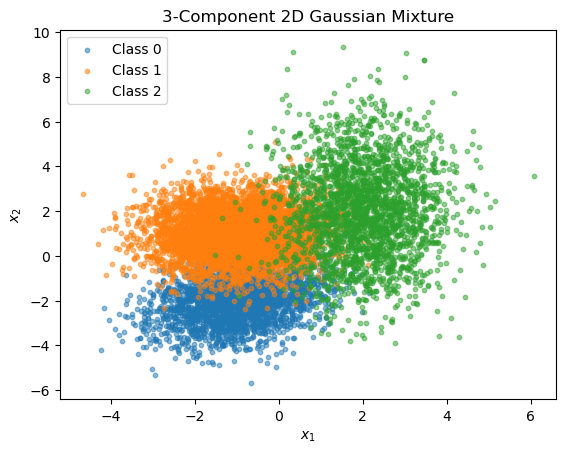

In [3]:
fig, axes = plt.subplots()
for k, g in df.groupby("class"):
    g.plot.scatter("x1", "x2", s=10, alpha=0.5, label=f"Class {k}", ax=axes, color=f"C{k}")
axes.set_title("3-Component 2D Gaussian Mixture")
axes.set_xlabel(r"$x_1$")
axes.set_ylabel(r"$x_2$")
axes.legend()

In [4]:

# set seed for reproducibility
train_df = df.sample(frac=0.7, random_state=123)   # 70% train
test_df  = df.drop(train_df.index)                 # 30% test

design = MS(['x1', 'x2'], intercept=False) # intercept already handled in LDA/QDA
X_train = design.fit_transform(train_df)

X_test = design.transform(test_df)


## KNN

### Fit

In [15]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, train_df['class'])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Performance

In [16]:
pred_train_knn = knn.predict(X_train)
pred_test_knn = knn.predict(X_test)

print("Train error rate (KNN):", np.mean(pred_train_knn != train_df['class']))
print("Test error rate (KNN):", np.mean(pred_test_knn != test_df['class']))

Train error rate (KNN): 0.06357142857142857
Test error rate (KNN): 0.102


### Visualization

Text(0, 0.5, 'x2')

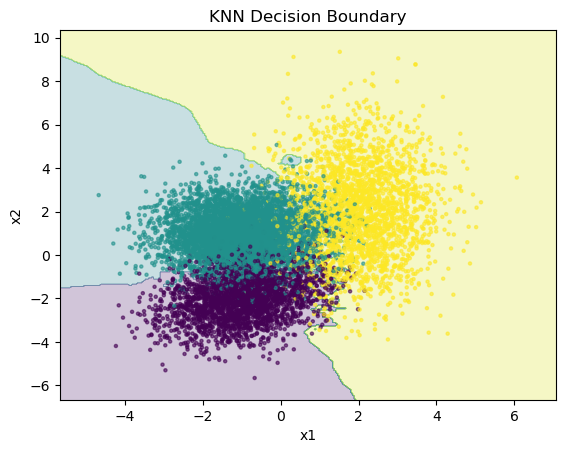

In [17]:
x1_min, x1_max = df["x1"].min() - 1, df["x1"].max() + 1
x2_min, x2_max = df["x2"].min() - 1, df["x2"].max() + 1
xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300),
)
grid = pd.DataFrame({"x1": xx1.ravel(), "x2": xx2.ravel()})
X_grid = design.transform(grid)

pred_knn = knn.predict(X_grid).astype(int).reshape(xx1.shape)

fig, axes = plt.subplots()

axes.contourf(xx1, xx2, pred_knn, alpha=0.25, cmap="viridis")
axes.scatter(df["x1"], df["x2"], c=df["class"], s=5, alpha=0.6, cmap="viridis")
axes.set_title("KNN Decision Boundary")
axes.set_xlabel("x1")
axes.set_ylabel("x2")


# Nonlinear Boundaries

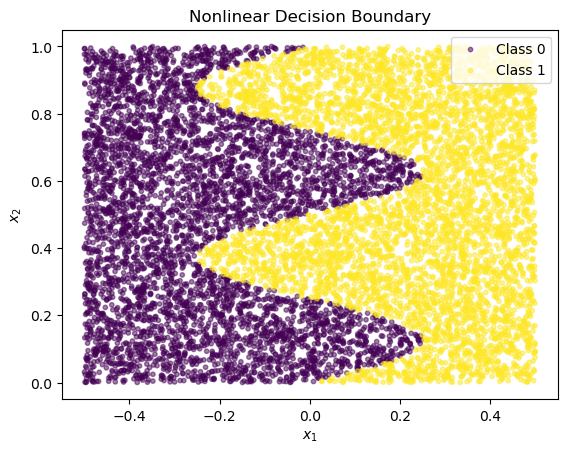

In [20]:

np.random.seed(318)
n = 10**4
x1 = np.random.uniform(-0.5, 0.5, n)
x2 = np.random.uniform(0, 1, n)

cls = 1 - (x1 < 0.25 * np.sin(4 * np.pi * x2)).astype(int)
nonlinear_df = pd.DataFrame({"x1": x1, "x2": x2, "class": pd.Categorical(cls)})

fig, ax = plt.subplots()
for k, g in nonlinear_df.groupby("class"):
    g.plot.scatter("x1", "x2", s=10, alpha=0.5, label=f"Class {k}", c='class',cmap="viridis", colorbar=False, ax=ax)
ax.set_title("Nonlinear Decision Boundary")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.legend()


In [21]:
train_df = nonlinear_df.sample(frac=0.7, random_state=123)   # 70% train
test_df  = nonlinear_df.drop(train_df.index)                 # 30% test



## Logistic

In [62]:
# train and test logistic
design = MS(['x1', 'x2'], intercept=True) 
X_train= design.fit_transform(train_df)
X_test = design.transform(test_df)
model = sm.GLM(train_df['class'], X_train, family=sm.families.Binomial())
logistic = model.fit()

prob_ = logistic.predict(X_train)
logistic_pred_train = (prob_ > 0.5).astype(int)
prob_ = logistic.predict(X_test)
logistic_pred_test = (prob_ > 0.5).astype(int)

print('Logistic:', np.mean(logistic_pred_train != train_df['class']),  np.mean(logistic_pred_test != test_df['class']))



Logistic: 0.1337142857142857 0.138


Text(0, 0.5, 'x2')

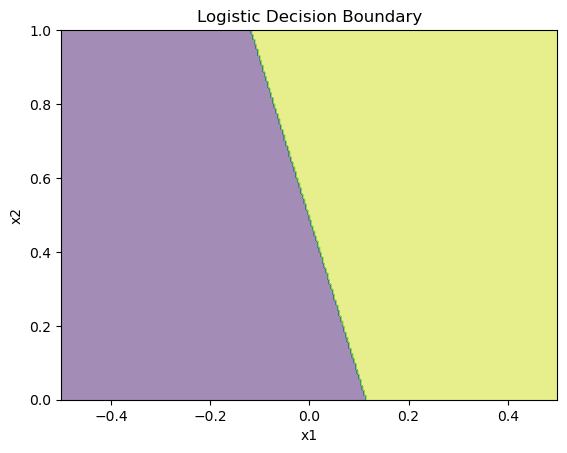

In [63]:
x1_min, x1_max = -0.5, 0.5
x2_min, x2_max = 0.0, 1.0
xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300),
)
grid = pd.DataFrame({"x1": xx1.ravel(), "x2": xx2.ravel()})
X_grid = design.transform(grid)

prob_ = logistic.predict(X_grid).to_numpy().reshape(xx1.shape)
pred_logistic = (prob_>0.5).astype(int) #.reshape(xx1.shape)

fig, axes = plt.subplots()

axes.contourf(xx1, xx2, pred_logistic, alpha=0.5, cmap="viridis")
# axes.scatter(df["x1"], df["x2"], c=df["class"], s=5, alpha=0.6, cmap="viridis")
axes.set_title("Logistic Decision Boundary")
axes.set_xlabel("x1")
axes.set_ylabel("x2")


## LDA

In [64]:
design = MS(['x1', 'x2'], intercept=False) 
X_train= design.fit_transform(train_df)
X_test = design.transform(test_df)

lda = LDA()
lda.fit(X_train, train_df['class'])

pred_train_lda = lda.predict(X_train)
pred_test_lda = lda.predict(X_test)

print('LDA:', np.mean(pred_train_lda != train_df['class']), np.mean(pred_test_lda != test_df['class']))


LDA: 0.13314285714285715 0.139


Text(0, 0.5, 'x2')

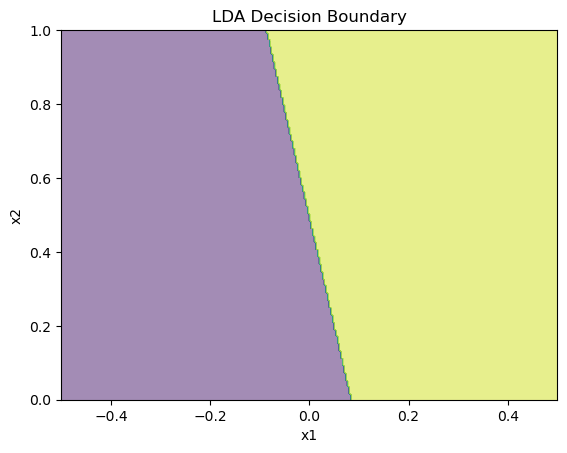

In [65]:
x1_min, x1_max = -0.5, 0.5
x2_min, x2_max = 0.0, 1.0
xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300),
)
grid = pd.DataFrame({"x1": xx1.ravel(), "x2": xx2.ravel()})
X_grid = design.transform(grid)

pred_lda = lda.predict(X_grid).reshape(xx1.shape)

fig, axes = plt.subplots()

axes.contourf(xx1, xx2, pred_lda, alpha=0.5, cmap="viridis")
# axes.scatter(df["x1"], df["x2"], c=df["class"], s=5, alpha=0.6, cmap="viridis")
axes.set_title("LDA Decision Boundary")
axes.set_xlabel("x1")
axes.set_ylabel("x2")


## QDA

In [66]:
qda = QDA()
qda.fit(X_train, train_df['class'])

pred_train_qda = qda.predict(X_train)
pred_test_qda = qda.predict(X_test)

print('QDA:', np.mean(pred_train_qda != train_df['class']), np.mean(pred_test_qda != test_df['class']))

QDA: 0.13357142857142856 0.13933333333333334


Text(0, 0.5, 'x2')

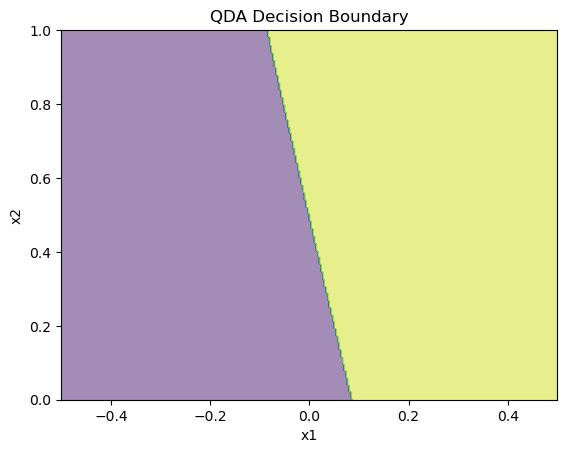

In [67]:
x1_min, x1_max = -0.5, 0.5
x2_min, x2_max = 0.0, 1.0
xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300),
)
grid = pd.DataFrame({"x1": xx1.ravel(), "x2": xx2.ravel()})
X_grid = design.transform(grid)

pred_qda = qda.predict(X_grid).reshape(xx1.shape)

fig, axes = plt.subplots()

axes.contourf(xx1, xx2, pred_qda, alpha=0.5, cmap="viridis")
# axes.scatter(df["x1"], df["x2"], c=df["class"], s=5, alpha=0.6, cmap="viridis")
axes.set_title("QDA Decision Boundary")
axes.set_xlabel("x1")
axes.set_ylabel("x2")


## KNN

In [ ]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train, train_df['class'])

pred_train_knn3 = knn3.predict(X_train)
pred_test_knn3 = knn3.predict(X_test)

print('KNN3:', np.mean(pred_train_knn3 != train_df['class']), np.mean(pred_test_knn3 != test_df['class']))

KNN3: 0.004428571428571428 0.008


Text(0, 0.5, 'x2')

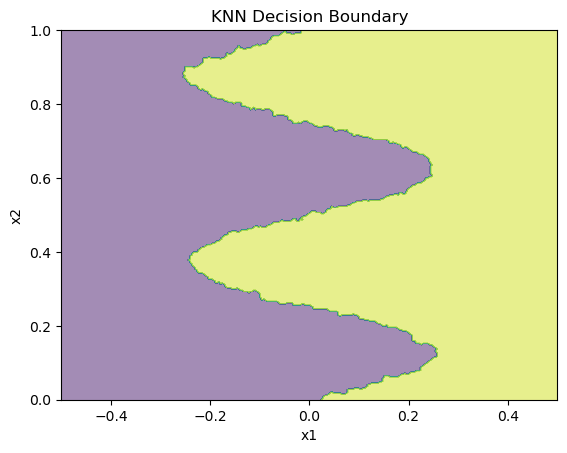

In [71]:
x1_min, x1_max = -0.5, 0.5
x2_min, x2_max = 0.0, 1.0
xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300),
)
grid = pd.DataFrame({"x1": xx1.ravel(), "x2": xx2.ravel()})
X_grid = design.transform(grid)

pred_knn = knn3.predict(X_grid).reshape(xx1.shape)

fig, axes = plt.subplots()

axes.contourf(xx1, xx2, pred_knn, alpha=0.5, cmap="viridis")
# axes.scatter(df["x1"], df["x2"], c=df["class"], s=5, alpha=0.6, cmap="viridis")
axes.set_title("KNN Decision Boundary")
axes.set_xlabel("x1")
axes.set_ylabel("x2")


# ROC and AUC

In [75]:
test_df['class']

0       1
1       0
13      1
16      1
17      1
       ..
9993    1
9995    1
9997    1
9998    1
9999    0
Name: class, Length: 3000, dtype: category
Categories (2, int64): [0, 1]

In [83]:
# match the class probability with the class of interest (class 1)
pred_knn3 = knn3.predict_proba(X_test)[:,1]
ytrue = (test_df['class'] == 1)

fpr, tpr, _ = roc_curve(ytrue, pred_knn3)
roc_auc = auc(fpr, tpr)
roc_auc

0.999739977349138

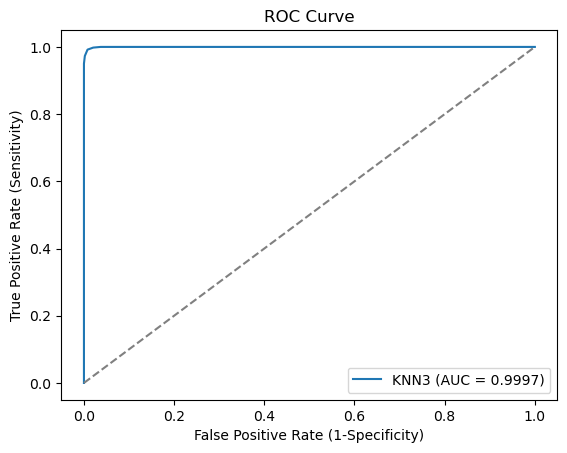

In [82]:
fig, axes = plt.subplots()
axes.plot(fpr, tpr, label=f"KNN3 (AUC = {roc_auc:.4f})")
axes.plot([0, 1], [0, 1], linestyle='--', color='gray')
axes.set_title("ROC Curve")
axes.set_xlabel("False Positive Rate (1-Specificity)")
axes.set_ylabel("True Positive Rate (Sensitivity)")
axes.legend()   

# Model Validation

## Variation in Predictions
Train data, once, generated from:
$$
y = 2 - 1.5 X_1 + \epsilon
$$
Test main times and check MSE

In [ ]:
# reset seed
np.random.seed(100)

# number of samples
n = 50
# create x values
x = np.random.uniform(0, 15, size=n)
# set true coefficients
beta0_true = 2.0
beta1_true = -1.5
# set noise parameters
eps = 1.0
y = beta0_true + beta1_true * x + eps * np.random.normal(size=n)

train_df = pd.DataFrame({"x": x, "y": y})

# linear model

design = MS(['x'])
X_train = design.fit_transform(train_df)

# X_train = sm.add_constant(train_df["x"])
lm_fit = sm.OLS(train_df["y"], X_train).fit()

# testing error
n_tests = 1000
mse = np.empty(n_tests)

for j in range(n_tests):
    x = np.random.uniform(0, 15, size=n)
    y = beta0_true + beta1_true * x + eps * np.random.normal(size=n)
    test_df = pd.DataFrame({"x": x, "y": y})
    X_test = design.transform(test_df)
    preds = lm_fit.predict(X_test)
    mse[j] = mean_squared_error(test_df["y"], preds)


Text(0, 0.5, 'Frequency')

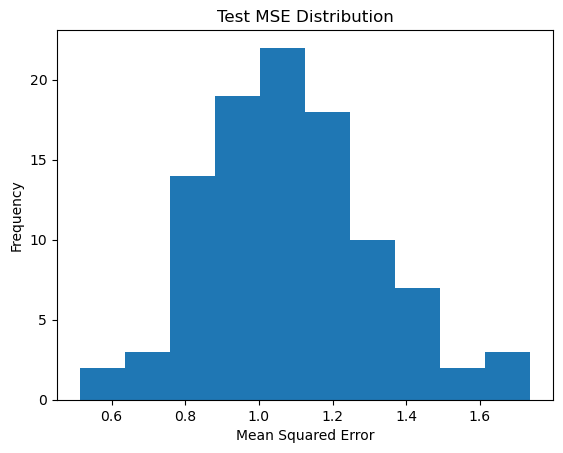

In [98]:
fig, axes = plt.subplots()
axes.hist(mse, bins=10)
axes.set_title("Test MSE Distribution")
axes.set_xlabel("Mean Squared Error")
axes.set_ylabel("Frequency")